# Question 3: Player Playstyle Archetype Clustering

This notebook uses `dataset/final_data` as the final output dataset and trains an unsupervised clustering model to group players into playstyle archetypes based on the defining characteristics of their favorite openings.


## Analysis Plan
1. Load the full cleaned chess dataset.
2. Build per-player opening histories from both White and Black perspectives.
3. Create favorite-opening feature vectors for each player.
4. Select the best number of clusters using silhouette score.
5. Train the clustering model and label the resulting archetypes.
6. Save tables and plots for your submission.


In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
DATA_PATH = Path('/Users/phamhoanghai/Ureca/dataset/final_data')
OUTPUT_DIR = Path('/Users/phamhoanghai/Ureca/Question_three/output')
PLOT_DIR = Path('/Users/phamhoanghai/Ureca/Question_three/plots')

MIN_GAMES_PER_PLAYER = 20
TOP_N_FAVORITE_OPENINGS = 3
RANDOM_STATE = 42
K_RANGE = range(3, 7)

FEATURE_COLUMNS = [
    'avg_elo',
    'opening_diversity',
    'favorite_opening_share',
    'favorite_openings_coverage',
    'family_closed_share',
    'family_flank_share',
    'family_indian_share',
    'family_open_share',
    'family_semi_open_share',
    'eco_a_share',
    'eco_b_share',
    'eco_c_share',
    'eco_d_share',
    'eco_e_share',
    'attackish_share',
    'defensive_share',
    'positional_share',
    'hypermodern_share',
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH.exists()


True

In [3]:
usecols = [
    'GameID', 'White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric',
    'ECO', 'Opening', 'OpeningFamily', 'NumericResult'
]

raw_df = pd.read_csv(DATA_PATH, usecols=usecols)
raw_df = raw_df.dropna(subset=['White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric', 'Opening', 'OpeningFamily', 'ECO']).copy()
print('Loaded shape:', raw_df.shape)
raw_df.head()


Loaded shape: (1111082, 9)


,GameID,White,Black,WhiteEloNumeric,BlackEloNumeric,ECO,Opening,NumericResult,OpeningFamily
0,1,sisy,lpaulmp,1645.0,1449.0,D31,Queen's Gambit Declined: Queen's Knight Variation,1.0,Closed and Semi-Closed
1,2,capablanca1950,ftri67,1603.0,1672.0,C00,French Defense,0.0,Open Games and Semi-Open
2,3,daamien,mike81,1166.0,1280.0,D00,Queen's Pawn Game: Steinitz Countergambit,1.0,Closed and Semi-Closed
3,4,yaavarmo,JACKELCALVO,1494.0,1449.0,C00,French Defense: Normal Variation,1.0,Open Games and Semi-Open
4,5,albinofrenchy,galita,1256.0,1285.0,D53,Queen's Gambit Declined: 4.Bg5 Be7,1.0,Closed and Semi-Closed


## Build Player-Level Game Rows
Each game is converted into two player-perspective rows so we can study opening behavior per player regardless of color.


In [4]:
white_rows = raw_df.rename(columns={'White': 'player', 'WhiteEloNumeric': 'player_elo'})[[
    'GameID', 'player', 'player_elo', 'Opening', 'OpeningFamily', 'ECO', 'NumericResult'
]].copy()
white_rows['perspective_score'] = white_rows['NumericResult']

black_rows = raw_df.rename(columns={'Black': 'player', 'BlackEloNumeric': 'player_elo'})[[
    'GameID', 'player', 'player_elo', 'Opening', 'OpeningFamily', 'ECO', 'NumericResult'
]].copy()
black_rows['perspective_score'] = 1 - black_rows['NumericResult']

player_games = pd.concat([white_rows, black_rows], ignore_index=True)
player_games['ECOGroup'] = player_games['ECO'].astype(str).str[0].str.upper()
print('Player-perspective rows:', player_games.shape)
player_games.head()


Player-perspective rows: (2222164, 9)


,GameID,player,player_elo,Opening,OpeningFamily,ECO,NumericResult,perspective_score,ECOGroup
0,1,sisy,1645.0,Queen's Gambit Declined: Queen's Knight Variation,Closed and Semi-Closed,D31,1.0,1.0,D
1,2,capablanca1950,1603.0,French Defense,Open Games and Semi-Open,C00,0.0,0.0,C
2,3,daamien,1166.0,Queen's Pawn Game: Steinitz Countergambit,Closed and Semi-Closed,D00,1.0,1.0,D
3,4,yaavarmo,1494.0,French Defense: Normal Variation,Open Games and Semi-Open,C00,1.0,1.0,C
4,5,albinofrenchy,1256.0,Queen's Gambit Declined: 4.Bg5 Be7,Closed and Semi-Closed,D53,1.0,1.0,D


In [5]:
def weighted_keyword_share(opening_counts: pd.Series, keywords: tuple[str, ...]) -> float:
    total = opening_counts.sum()
    if total == 0:
        return 0.0
    mask = opening_counts.index.to_series().str.lower().apply(lambda name: any(keyword in name for keyword in keywords))
    return float(opening_counts[mask.values].sum() / total)

eligible = player_games.groupby('player').filter(lambda frame: len(frame) >= MIN_GAMES_PER_PLAYER).copy()
print('Eligible player rows:', eligible.shape)
print('Eligible unique players:', eligible['player'].nunique())


Eligible player rows: (2132503, 9)
Eligible unique players: 12888


In [6]:
records = []
favorite_rows = []

for player, frame in eligible.groupby('player', sort=False):
    opening_counts = frame['Opening'].value_counts()
    favorite_counts = opening_counts.head(TOP_N_FAVORITE_OPENINGS)
    favorite_openings = favorite_counts.index.tolist()
    favorite_frame = frame[frame['Opening'].isin(favorite_openings)].copy()

    total_games = len(frame)
    favorite_total_games = int(favorite_counts.sum())

    family_share = (
        favorite_frame['OpeningFamily']
        .value_counts(normalize=True)
        .reindex([
            'Closed and Semi-Closed',
            'Flank Openings',
            'Indian Defenses',
            'Open Games and Semi-Open',
            'Semi-Open Defenses',
        ], fill_value=0.0)
    )

    eco_share = (
        favorite_frame['ECOGroup']
        .value_counts(normalize=True)
        .reindex(list('ABCDE'), fill_value=0.0)
    )

    top_opening = favorite_counts.index[0]
    top_opening_games = int(favorite_counts.iloc[0])

    for opening_name, count in favorite_counts.items():
        favorite_rows.append({
            'player': player,
            'opening': opening_name,
            'games': int(count),
            'share_within_player': float(count / total_games),
        })

    records.append({
        'player': player,
        'games_played': total_games,
        'avg_elo': float(frame['player_elo'].mean()),
        'mean_score': float(frame['perspective_score'].mean()),
        'opening_diversity': int(frame['Opening'].nunique()),
        'favorite_opening': top_opening,
        'favorite_opening_games': top_opening_games,
        'favorite_opening_share': float(top_opening_games / total_games),
        'favorite_openings_coverage': float(favorite_total_games / total_games),
        'family_closed_share': float(family_share['Closed and Semi-Closed']),
        'family_flank_share': float(family_share['Flank Openings']),
        'family_indian_share': float(family_share['Indian Defenses']),
        'family_open_share': float(family_share['Open Games and Semi-Open']),
        'family_semi_open_share': float(family_share['Semi-Open Defenses']),
        'eco_a_share': float(eco_share['A']),
        'eco_b_share': float(eco_share['B']),
        'eco_c_share': float(eco_share['C']),
        'eco_d_share': float(eco_share['D']),
        'eco_e_share': float(eco_share['E']),
        'attackish_share': weighted_keyword_share(favorite_counts, ('attack', 'gambit', 'sacrifice', 'storm')),
        'defensive_share': weighted_keyword_share(favorite_counts, ('defense', 'defence', 'declined')),
        'positional_share': weighted_keyword_share(favorite_counts, ('system', 'london', 'english', 'reti', 'catalan', "queen's gambit", 'slav', 'caro-kann')),
        'hypermodern_share': weighted_keyword_share(favorite_counts, ('indian', 'modern', 'pirc', 'reti', 'english', 'bird', 'owen', 'larsen', 'grunfeld', 'benoni')),
    })

player_profiles = pd.DataFrame(records).sort_values(['games_played', 'avg_elo'], ascending=[False, False]).reset_index(drop=True)
favorite_detail = pd.DataFrame(favorite_rows)
print('Player profile shape:', player_profiles.shape)
player_profiles.head()


Player profile shape: (12888, 23)


,player,games_played,avg_elo,mean_score,opening_diversity,favorite_opening,favorite_opening_games,favorite_opening_share,favorite_openings_coverage,family_closed_share,family_flank_share,family_indian_share,family_open_share,family_semi_open_share,eco_a_share,eco_b_share,eco_c_share,eco_d_share,eco_e_share,attackish_share,defensive_share,positional_share,hypermodern_share
0,cocochess,6380,1915.064420,0.669671,383,Owen Defense,435,0.068182,0.133229,0.0,0.256471,0.0,0.000000,0.743529,0.256471,0.743529,0.000000,0.0,0.0,0.000000,0.743529,0.000000,0.511765
1,IgorKoc,5125,2000.122732,0.744780,277,Scandinavian Defense,372,0.072585,0.170927,0.0,0.000000,0.0,0.575342,0.424658,0.000000,0.424658,0.575342,0.0,0.0,0.000000,0.699772,0.000000,0.000000
2,aavza50,4531,1633.904215,0.529133,172,Van't Kruijs Opening,1182,0.260870,0.484882,0.0,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,faryad22,3091,1843.109026,0.489486,169,Hungarian Opening,792,0.256228,0.431252,0.0,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.240810,0.000000
4,igo1,3031,2118.773012,0.604751,262,King's Indian Attack,219,0.072253,0.185087,0.0,0.629234,0.0,0.000000,0.370766,0.629234,0.370766,0.000000,0.0,0.0,0.390374,0.370766,0.370766,0.390374


## Train The Clustering Model
This is the model-training step for Question 3. Since this task is unsupervised, the training process fits KMeans on engineered player opening features.


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(player_profiles[FEATURE_COLUMNS])

silhouette_results = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append({'k': k, 'silhouette_score': float(score)})

silhouette_df = pd.DataFrame(silhouette_results).sort_values('silhouette_score', ascending=False).reset_index(drop=True)
best_k = int(silhouette_df.iloc[0]['k'])
print('Best k:', best_k)
silhouette_df


Best k: 5


,k,silhouette_score
0,5,0.239818
1,6,0.237508
2,4,0.209355
3,3,0.194098


In [8]:
cluster_model = KMeans(n_clusters=best_k, n_init=50, random_state=RANDOM_STATE)
player_profiles = player_profiles.copy()
player_profiles['cluster_id'] = cluster_model.fit_predict(X_scaled)

centers_original = pd.DataFrame(
    scaler.inverse_transform(cluster_model.cluster_centers_),
    columns=FEATURE_COLUMNS,
)
centers_original['cluster_id'] = range(best_k)

def infer_cluster_label(center: pd.Series) -> str:
    family_scores = {
        'closed': center['family_closed_share'],
        'flank': center['family_flank_share'],
        'indian': center['family_indian_share'],
        'open': center['family_open_share'],
        'semi_open': center['family_semi_open_share'],
    }
    dominant_family = max(family_scores, key=family_scores.get)

    if dominant_family == 'flank':
        return 'Hypermodern Strategists'
    if dominant_family == 'indian':
        return 'Indian Defense Specialists'
    if dominant_family == 'closed':
        return 'Positional Defenders'
    if dominant_family == 'semi_open':
        return 'Counterpunching Defenders'
    if dominant_family == 'open':
        if center['attackish_share'] >= 0.18:
            return 'Aggressive Attackers'
        return 'Open-Game Technicians'
    return 'Flexible Universalists'

centers_original['archetype'] = centers_original.apply(infer_cluster_label, axis=1)
label_map = centers_original.set_index('cluster_id')['archetype'].to_dict()
player_profiles['archetype'] = player_profiles['cluster_id'].map(label_map)

print('Players clustered:', len(player_profiles))
print('Archetypes found:', player_profiles['archetype'].nunique())
centers_original.sort_values('cluster_id')


Players clustered: 12888
Archetypes found: 5


,avg_elo,opening_diversity,favorite_opening_share,favorite_openings_coverage,family_closed_share,family_flank_share,family_indian_share,family_open_share,family_semi_open_share,eco_a_share,eco_b_share,eco_c_share,eco_d_share,eco_e_share,attackish_share,defensive_share,positional_share,hypermodern_share,cluster_id,archetype
0,1622.857305,51.274493,0.192348,0.365839,0.034209,0.699099,0.000339,0.089135,0.177219,0.699099,0.177219,0.089135,0.034209,0.000339,0.113077,0.423118,0.138907,0.365590,0,Hypermodern Strategists
1,1516.289414,58.753369,0.112645,0.246823,0.027582,0.056410,0.000032,0.778097,0.137879,0.056410,0.137879,0.778097,0.027582,0.000032,0.198103,0.602606,0.028123,0.042875,1,Aggressive Attackers
2,1642.352998,68.271345,0.115062,0.245463,0.043231,0.104909,0.000263,0.136918,0.714678,0.104909,0.714678,0.136918,0.043231,0.000263,0.195898,0.868533,0.131572,0.177413,2,Counterpunching Defenders
3,1578.937182,56.217080,0.124986,0.267804,0.551119,0.174157,0.000398,0.147881,0.126445,0.174157,0.126445,0.147881,0.551119,0.000398,0.281763,0.453441,0.263998,0.084404,3,Positional Defenders
4,1742.642457,53.901786,0.093560,0.212584,0.165337,0.155216,0.330737,0.115567,0.233143,0.155216,0.233143,0.115567,0.165337,0.330737,0.190380,0.771186,0.245267,0.411441,4,Indian Defense Specialists


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
player_profiles['pca_1'] = coords[:, 0]
player_profiles['pca_2'] = coords[:, 1]

cluster_summary = (
    player_profiles.groupby(['cluster_id', 'archetype'], as_index=False)
    .agg(
        players=('player', 'count'),
        mean_games=('games_played', 'mean'),
        mean_elo=('avg_elo', 'mean'),
        mean_opening_diversity=('opening_diversity', 'mean'),
        mean_favorite_share=('favorite_opening_share', 'mean'),
        mean_top3_coverage=('favorite_openings_coverage', 'mean'),
        mean_score=('mean_score', 'mean'),
    )
    .sort_values(['players', 'mean_elo'], ascending=[False, False])
    .reset_index(drop=True)
)

cluster_summary


,cluster_id,archetype,players,mean_games,mean_elo,mean_opening_diversity,mean_favorite_share,mean_top3_coverage,mean_score
0,1,Aggressive Attackers,4451,146.233431,1516.231820,58.737587,0.112658,0.246849,0.472173
1,2,Counterpunching Defenders,3749,182.197119,1642.387750,68.287543,0.115046,0.245433,0.504150
2,0,Hypermodern Strategists,2368,190.627534,1622.857305,51.274493,0.192348,0.365839,0.477994
3,3,Positional Defenders,2096,154.777672,1578.937182,56.217080,0.124986,0.267804,0.493321
4,4,Indian Defense Specialists,224,101.522321,1742.642457,53.901786,0.093560,0.212584,0.526313


In [10]:
top_openings_by_cluster = (
    favorite_detail.merge(player_profiles[['player', 'cluster_id', 'archetype']], on='player', how='left')
    .groupby(['cluster_id', 'archetype', 'opening'], as_index=False)['games']
    .sum()
    .sort_values(['cluster_id', 'games'], ascending=[True, False])
)
top_openings_by_cluster = top_openings_by_cluster.groupby(['cluster_id', 'archetype'], group_keys=False).head(10).reset_index(drop=True)
top_openings_by_cluster.head(20)


,cluster_id,archetype,opening,games
0,0,Hypermodern Strategists,Van't Kruijs Opening,22862
1,0,Hypermodern Strategists,Hungarian Opening,14673
2,0,Hypermodern Strategists,Modern Defense,11231
3,0,Hypermodern Strategists,Owen Defense,9950
4,0,Hypermodern Strategists,Mieses Opening,5864
5,0,Hypermodern Strategists,Horwitz Defense,5504
6,0,Hypermodern Strategists,Bird Opening,5263
7,0,Hypermodern Strategists,Nimzo-Larsen Attack,4889
8,0,Hypermodern Strategists,English Defense #2,4618
9,0,Hypermodern Strategists,Polish Opening,4017


## Visualize Cluster Quality And Archetypes


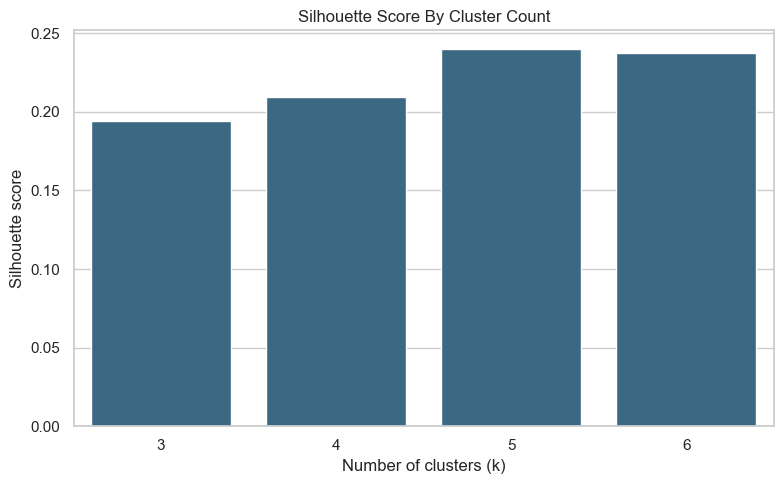

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=silhouette_df, x='k', y='silhouette_score', color='#2f6c8f')
plt.title('Silhouette Score By Cluster Count')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.show()


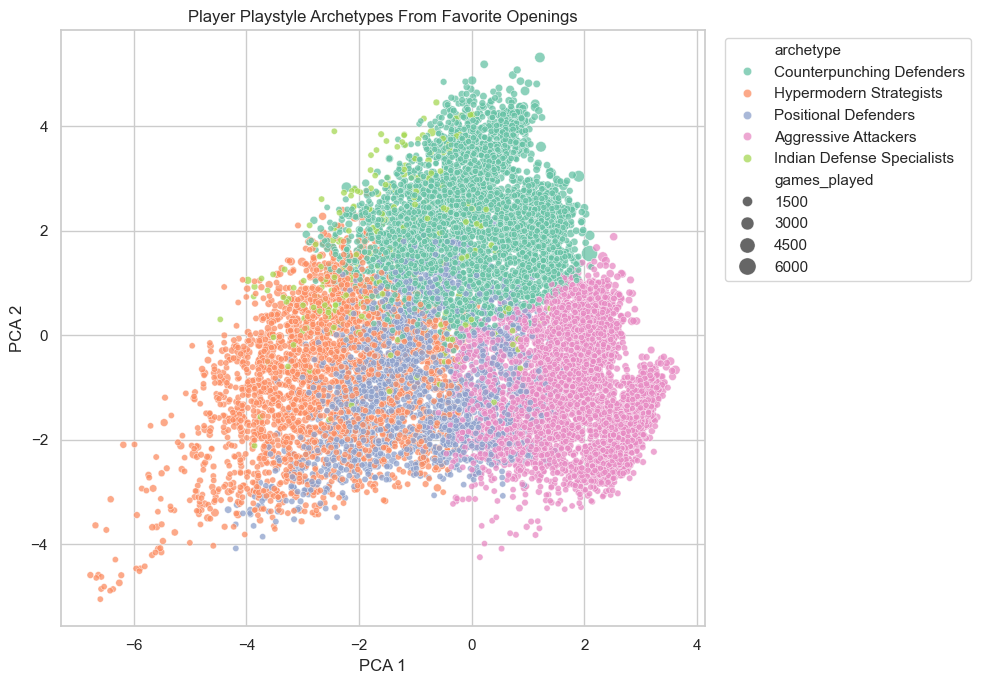

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=player_profiles,
    x='pca_1',
    y='pca_2',
    hue='archetype',
    size='games_played',
    sizes=(20, 160),
    alpha=0.75,
    palette='Set2',
)
plt.title('Player Playstyle Archetypes From Favorite Openings')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


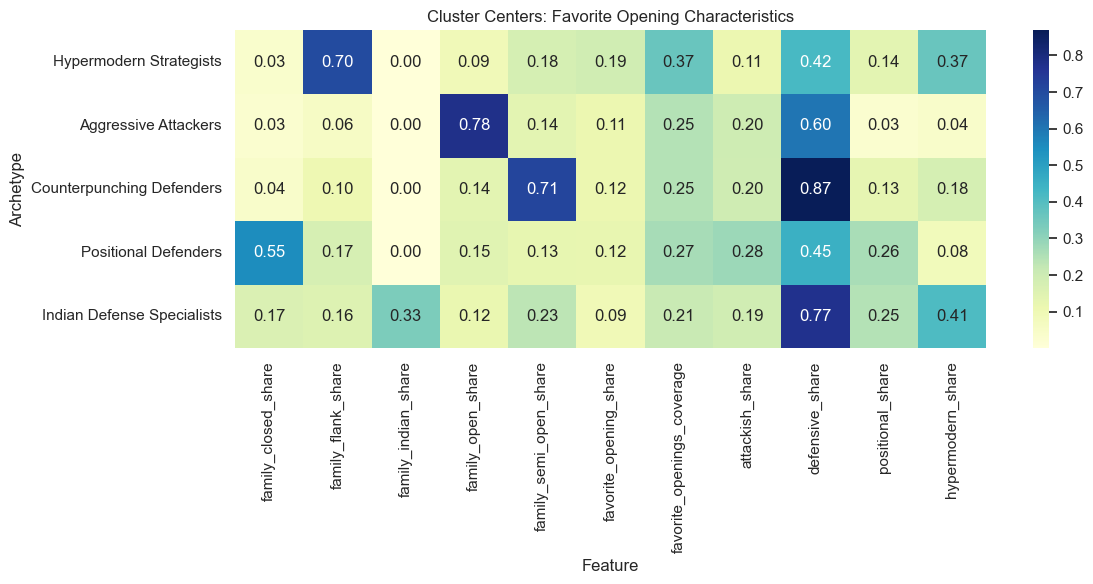

In [13]:
heatmap_cols = [
    'family_closed_share', 'family_flank_share', 'family_indian_share',
    'family_open_share', 'family_semi_open_share', 'favorite_opening_share',
    'favorite_openings_coverage', 'attackish_share', 'defensive_share',
    'positional_share', 'hypermodern_share'
]

heatmap_df = centers_original.sort_values('cluster_id').set_index('archetype')[heatmap_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Centers: Favorite Opening Characteristics')
plt.xlabel('Feature')
plt.ylabel('Archetype')
plt.tight_layout()
plt.show()


## Save Submission Outputs


In [14]:
player_profiles.sort_values(['cluster_id', 'games_played'], ascending=[True, False]).to_csv(OUTPUT_DIR / 'player_archetypes.csv', index=False)
centers_original.sort_values('cluster_id').to_csv(OUTPUT_DIR / 'cluster_feature_centers.csv', index=False)
cluster_summary.to_csv(OUTPUT_DIR / 'cluster_summary.csv', index=False)
silhouette_df.to_csv(OUTPUT_DIR / 'silhouette_scores.csv', index=False)
top_openings_by_cluster.to_csv(OUTPUT_DIR / 'top_openings_by_cluster.csv', index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=silhouette_df, x='k', y='silhouette_score', color='#2f6c8f')
plt.title('Silhouette Score By Cluster Count')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'silhouette_scores.png', dpi=200)
plt.close()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=player_profiles, x='pca_1', y='pca_2', hue='archetype', size='games_played', sizes=(20, 160), alpha=0.75, palette='Set2')
plt.title('Player Playstyle Archetypes From Favorite Openings')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'player_archetypes_pca.png', dpi=200)
plt.close()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Centers: Favorite Opening Characteristics')
plt.xlabel('Feature')
plt.ylabel('Archetype')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'cluster_feature_heatmap.png', dpi=200)
plt.close()

print('Saved notebook outputs to:')
print(OUTPUT_DIR)
print(PLOT_DIR)


Saved notebook outputs to:
/Users/phamhoanghai/Ureca/Question_three/output
/Users/phamhoanghai/Ureca/Question_three/plots


In [15]:
cluster_summary


,cluster_id,archetype,players,mean_games,mean_elo,mean_opening_diversity,mean_favorite_share,mean_top3_coverage,mean_score
0,1,Aggressive Attackers,4451,146.233431,1516.231820,58.737587,0.112658,0.246849,0.472173
1,2,Counterpunching Defenders,3749,182.197119,1642.387750,68.287543,0.115046,0.245433,0.504150
2,0,Hypermodern Strategists,2368,190.627534,1622.857305,51.274493,0.192348,0.365839,0.477994
3,3,Positional Defenders,2096,154.777672,1578.937182,56.217080,0.124986,0.267804,0.493321
4,4,Indian Defense Specialists,224,101.522321,1742.642457,53.901786,0.093560,0.212584,0.526313
